# Analyze RNNs

In [1]:
from utilities.utils import *
from utilities.RNN import *
from matplotlib import pyplot as plt
import numpy as np
import scipy
import random
import torch
from sklearn.manifold import TSNE
import pickle
import pandas as pd
from statsmodels.stats.anova import AnovaRM
from matplotlib.colors import LinearSegmentedColormap
from dPCA_master.python.dPCA import dPCA

### Load experimental data and variables

In [2]:
# we'll want the experimental data for comparison ... load it now

with open('data/model/experimental_input.pkl', 'rb') as file:
    experimental_input = pickle.load(file)
    file.close()
    
all_data = experimental_input['all_data']
included_sessions = list(all_data.keys())
n_sessions = len(included_sessions)
params = experimental_input['parameters']
bin_size = params['bin_size']
padding = params['padding']
smooth_type = params['smooth_type']
smooth_width = params['smooth_width']

### Load model data and variables

In [3]:
# load pre-trained models

with open('data/model/all_models.pkl', 'rb') as file:
    all_models = pickle.load(file) 
    file.close()
    
with open('data/model/hyperparameters.pkl', 'rb') as file:
    hyp = pickle.load(file) 
    file.close()

# re-define important variables for the models (inputs, etc.)

_, y_conc, _, _, t = all_data[included_sessions[0]]
unique_stims = np.unique(y_conc)
n_stims = len(unique_stims)
colors = np.hstack([
    np.reshape(np.linspace(0, 1, n_stims), (-1, 1)),
    np.reshape(np.linspace(1, 0, n_stims), (-1, 1)),
    np.reshape(np.linspace(0, 1, n_stims), (-1, 1))
])
n_bins = len(t)
input_size = hyp['input_size']
stim_start = hyp['stim_start']
stim_end = hyp['stim_end']
t_stim_window = (t >= stim_start) & (t <= stim_end)
t_D = t[-1] + bin_size / 2 - padding  # decision time point
decision_pre_time = hyp['decision_pre_time'] # pre-decision time point window
t_decision_window = (t > t_D - decision_pre_time) & (t <= t_D)
t_target_window = (t < 0) | t_decision_window
inputs = np.zeros((n_stims, n_bins, input_size))
for i_stim, stim in enumerate(unique_stims):
    inputs[i_stim, :, :] = np.tile( np.array([stim / 100, 1 - stim / 100]), (n_bins, 1) )
inputs[:, ~t_stim_window, :] = 0  # stimulus is only present within [stim_start, stim_end]
inputs = torch.from_numpy(inputs).to(dtype=torch.float32)  # convert to tensor

window_width = 4
window_step = 4

fit_options = [
    {
        'shape' : 'linear',
        'y_min' : 0,
        'y_max' : np.inf,
        'min_y_range' : 0
    },
    {
        'shape' : 'step',
        'midpoints' : [40, 50, 60],
        'min_y_range' : 0
    }
]

n_windows = 1 + (n_bins - window_width) // window_step
inds_L = [i * window_step for i in range(n_windows)]
inds_R = [ind + window_width for ind in inds_L]
t_downsample = [np.mean(t[ind_L:ind_R]) for ind_L, ind_R in zip(inds_L, inds_R)]

### Find a noise level for each model that puts its accuracy near its corresponding animal's

In [4]:
try:
    with open('data/model/inputs_sigma.pkl', 'rb') as file:
        inputs_sigma = pickle.load(file)
        file.close()
except:
    accs_animal = []
    accs_model = []
    inputs_sigma = {}
    for session in included_sessions:
        print('Session {}'.format(session))
        acc_animal = 100 * np.mean(all_data[session][3])
        accs_animal.append(acc_animal)
        print('    Animal accuracy: {:.1f}%'.format(acc_animal))
        sigma = 0.4
        output_temp = model_simulation(
            all_models[session], 
            inputs, 
            unique_stims, 
            t_decision_window,
            n_trials_per_stim=60, 
            sigma=sigma,
            silenced=None,
            label_data=None, 
            responses_over_time=False,
            fit_options=None,
            inds_L=None, 
            inds_R=None,
            responses_beginning_end=False,
            window_beginning=None,
            window_end=None)
        acc_model = output_temp['accuracy']
        print('    sigma = {:.2f}, model accuracy: {:.1f}%'.format(sigma, acc_model))
        while np.abs(acc_model - acc_animal) > 5:
            if acc_model < acc_animal:
                sigma -= 0.05
            elif acc_model > acc_animal:
                sigma += 0.05
            output_temp = model_simulation(
                all_models[i_session], 
                inputs, 
                unique_stims, 
                t_decision_window,
                n_trials_per_stim=60, 
                sigma=sigma,
                silenced=None,
                label_data=None, 
                responses_over_time=False,
                fit_options=None,
                inds_L=None, 
                inds_R=None,
                responses_beginning_end=False,
                window_beginning=None,
                window_end=None)
            acc_model = output_temp['accuracy']
            print('    sigma = {:.2f}, model accuracy: {:.1f}%'.format(sigma, acc_model))
        accs_model.append(acc_model)
        inputs_sigma[session] = sigma
    with open('data/model/inputs_sigma.pkl', 'wb') as file:
        pickle.dump(inputs_sigma, file)
        file.close()

In [5]:
print('Model noise levels:')
print('    Min: {:.4f}'.format(np.min(list(inputs_sigma.values()))))
print('    Max: {:.4f}'.format(np.max(list(inputs_sigma.values()))))
print('    Mean: {:.4f}'.format(np.mean(list(inputs_sigma.values()))))

Model noise levels:
    Min: 0.1000
    Max: 1.1500
    Mean: 0.4304


### Run 'control' (no ablations) simulations using these noise parameters

In [6]:
try:
    with open('data/model/output_tailored_noise.pkl', 'rb') as file:
        output_noise = pickle.load(file)
        file.close()
except:
    output_noise = multi_model_simulation(
        all_models, 
        inputs, 
        unique_stims, 
        t_decision_window,
        n_trials_per_stim=n_trials_per_stim, 
        sigma=inputs_sigma,
        silenced=None,
        label_data=None, 
        responses_over_time=True,
        fit_options=fit_options,
        inds_L=inds_L, 
        inds_R=inds_R,
        responses_beginning_end=True,
        window_beginning=((t >= stim_start) & (t <= stim_start + 0.5)),
        window_end=((t >= t_D - 0.5) & (t <= t_D)))
    with open('data/model/output_tailored_noise.pkl', 'wb') as file:
        pickle.dump(output_noise, file)
        file.close()

### Analyze the behavioral performance

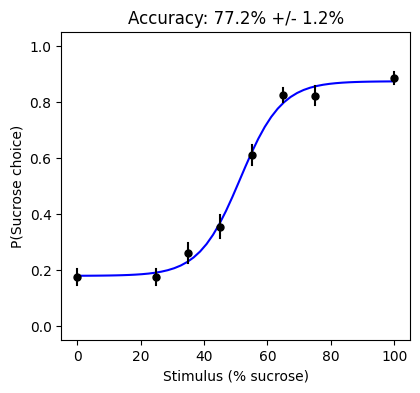

In [7]:
fig, ax = plt.subplots(figsize=(4.5, 4));
p_left_mat = np.empty([0, n_stims])
p_left_mat_exp = np.empty([0, n_stims])
for session in included_sessions:
    p_left = output_noise['all_p_left'][session]
    p_left_mat = np.vstack([p_left_mat, p_left])
    p_left_exp = np.array([all_data[session][2].flatten()[all_data[session][1].flatten() == stim].mean()
                           for stim in unique_stims])
    p_left_mat_exp = np.vstack([p_left_mat_exp, p_left_exp])
ave_p_left = p_left_mat.mean(axis=0)
std_p_left = p_left_mat.std(axis=0) / np.sqrt(p_left_mat.shape[0])
psycho_res = fit_psychometric(unique_stims, ave_p_left)
ax.plot(psycho_res['x'], psycho_res['y'], 'b');
for i_stim, stim in enumerate(unique_stims):
    ax.plot([stim, stim], [ave_p_left[i_stim] - std_p_left[i_stim], ave_p_left[i_stim] + std_p_left[i_stim]], 'k');
    ax.plot(stim, ave_p_left[i_stim], '.k', markersize=10);
ax.set_ylim([-0.05, 1.05]);
ax.set_xlabel('Stimulus (% sucrose)');
ax.set_ylabel('P(Sucrose choice)');
accs = [output_noise['all_accuracies'][session] for session in included_sessions]
accs_exp = []
for session in included_sessions:
    mask = np.array([s in unique_stims for s in all_data[session][1]])
    accs_exp.append(all_data[session][3][mask].mean())
ax.set_title('Accuracy: {:.1f}% +/- {:.1f}%'.format(100 * np.mean(accs), 100 * np.std(accs) / np.sqrt(n_sessions)));

# Figure 5B
# plt.savefig('plots/model/model_accuracy.pdf');

In [8]:
# compare experiment and model
Y = np.array([p_left_mat.mean(axis=0), p_left_mat_exp.mean(axis=0)])

psycho_res_model = fit_psychometric(unique_stims, Y[0, :])
print('Model psychometric slope: {:.4f}'.format(psycho_res_model['slope']))
psycho_res_exp = fit_psychometric(unique_stims, Y[1, :])
print('Experiment psychometric slope: {:.4f}\n'.format(psycho_res_exp['slope']))

res = psychometric_comparison_test(unique_stims, Y)
print('Psychometric comparison:')
print('    F = {:.4f}'.format(res['F']))
print('    p = {:.4f}\n'.format(res['p']))

print('Model mean accuracy: {:.4f}%'.format(100 * np.mean(accs)))
print('Animal mean accuracy: {:.4f}%'.format(100 * np.mean(accs_exp)))
res = scipy.stats.ttest_ind(accs, accs_exp)
print('Accuracy comparison via t test: p = {:.4f}'.format(res.pvalue))
res = scipy.stats.mannwhitneyu(accs, accs_exp)
print('Accuracy comparison via rank sum: p = {:.4f}'.format(res.pvalue))

Model psychometric slope: 0.1534
Experiment psychometric slope: 0.0764

Psychometric comparison:
    F = 16.0334
    p = 0.0007

Model mean accuracy: 77.2283%
Animal mean accuracy: 77.1598%
Accuracy comparison via t test: p = 0.9644
Accuracy comparison via rank sum: p = 0.8864


### Analyze goodness of fit to neural data

In [9]:
ys = []
y_hats = []

for session in included_sessions:
    
    X, y_conc, y_choice, y_outcome, _ = all_data[session]
    n_neurons = X.shape[1]
    
    y = np.zeros((n_stims, n_bins, n_neurons))
    for i_stim, stim in enumerate(unique_stims):
        trial_mask = (y_conc == stim) & (y_outcome == 1)
        for i_neuron in range(n_neurons):
            psth = X[trial_mask, i_neuron, :].mean(axis=0)
            y[i_stim, :, i_neuron] = psth
    
    net = all_models[session]
    # turn off internal noise too for this simulation
    net_no_noise = net.clone()
    net_no_noise.noise_std = 0
    output, traj = net_no_noise(inputs, initial_states=None, return_dynamics=True)
    y_hat = output[:, :, :n_neurons].detach().numpy()
    
    ys.append(y)
    y_hats.append(y_hat)

sses_all = []
for i_session in range(len(ys)):
    sses = []
    for i_neuron in range(ys[i_session].shape[2]):
        sse = 0
        for i_stim, stim in enumerate(unique_stims):
            y = ys[i_session][i_stim, :, i_neuron]
            y_hat = y_hats[i_session][i_stim, :, i_neuron]
            sse += ((y - y_hat) ** 2).sum()
        sse /= (n_stims * n_bins)
        sses.append(sse)
    sses_all.append(sses)

In [10]:
sses = []
for sses_ in sses_all:
    sses += sses_

print('Mean MSE: {:.4f}'.format(np.mean(sses)))
print('Median MSE: {:.4f}'.format(np.median(sses)))
print('Mean RMSE: {:.4f}'.format(np.mean(np.sqrt(sses))))
print('Median RMSE: {:.4f}'.format(np.median(np.sqrt(sses))))

Mean MSE: 4.6732
Median MSE: 1.5768
Mean RMSE: 1.6290
Median RMSE: 1.2557


SSE: 3.3279
RSSE: 1.8243


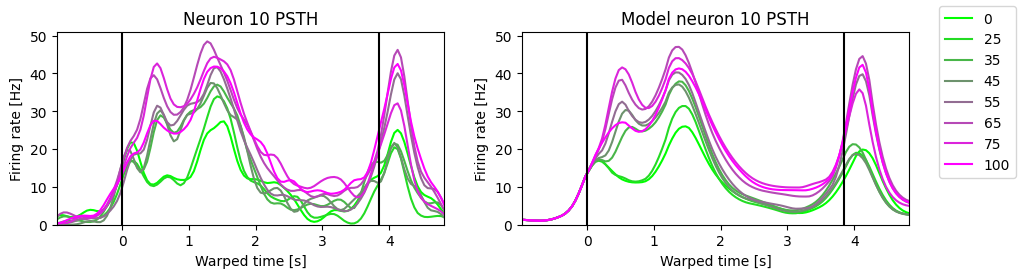

In [11]:
## example constrained neuron (no noise)

i_session = 2
i_neuron = 9

fig, axes = plt.subplots(1, 2, figsize=(11, 2.5));
sse = 0
for i_stim, stim in enumerate(unique_stims):
    y = ys[i_session][i_stim, :, i_neuron]
    y_hat = y_hats[i_session][i_stim, :, i_neuron]
    sse += ((y - y_hat) ** 2).sum()
    axes[0].plot(t, y, color=colors[i_stim, :]);
    axes[1].plot(t, y_hat, color=colors[i_stim, :]);
sse = sse / n_stims / n_bins
fig.legend([stim for stim in unique_stims]);
for i_ax, ax in enumerate(axes):
    ax.set_xlim([t[0], t[-1]]);
    ax.set_xlabel('Warped time [s]');
    y_max = max([ax.get_ylim()[1] for ax in axes])
    ax.set_ylim([0, y_max]);
    ax.set_ylabel('Firing rate [Hz]');
    ax.axvline(0, color='k');
    ax.axvline(t_D, color='k'); 
    if (i_ax == 0):
        ax.title.set_text('Neuron {} PSTH'.format(i_neuron + 1));
    elif (i_ax == 1):
        ax.title.set_text('Model neuron {} PSTH'.format(i_neuron + 1));
        
# Figure 5C
# plt.savefig('plots/model/model_example_constrained_psth_5.pdf');

print('SSE: {:.4f}'.format(sse))
print('RSSE: {:.4f}'.format(np.sqrt(sse)))

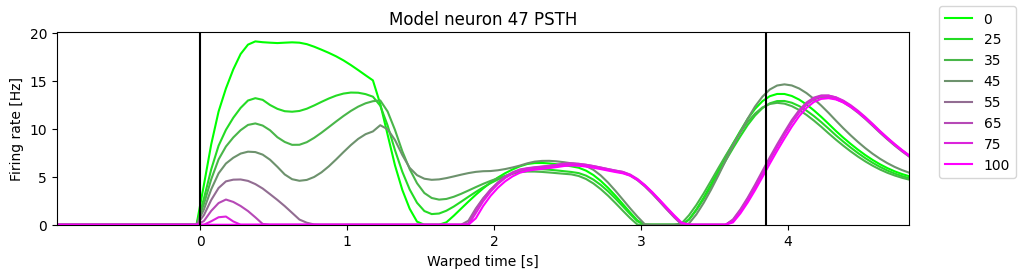

In [12]:
## example unconstrained neuron (no noise)

i_session = 1
i_neuron = 3

fig, ax = plt.subplots(figsize=(11, 2.5));
net = all_models[i_session].clone()
net.noise_std = 0
n_neurons = net.observed_size
_, traj = net(inputs, initial_states=None, return_dynamics=True)
y_hats = net.non_linearity(traj[:, 1:, :].detach() + net.b.detach()).numpy()
for i_stim, stim in enumerate(unique_stims):
    y_hat = y_hats[i_stim, :, n_neurons + i_neuron]
    ax.plot(t, y_hat, color=colors[i_stim, :]);
fig.legend([stim for stim in unique_stims]);
ax.set_xlim([t[0], t[-1]]);
ax.set_xlabel('Warped time [s]');
ax.set_ylim([0, ax.get_ylim()[1]]);
ax.set_ylabel('Firing rate [Hz]');
ax.axvline(0, color='k');
ax.axvline(t_D, color='k'); 
ax.title.set_text('Model neuron {} PSTH'.format(n_neurons + i_neuron));

# Figure 5D
# plt.savefig('plots/model/model_example_unconstrained_psth.pdf');

### Responsivity and selectivity

In [13]:
try:
    with open('data/model/responsivity_and_selectivity.pkl', 'rb') as file:
        res = pickle.load(file)
        file.close()
except:
    res = model_responsive_and_selective_tests(output_noise, included_sessions, t, 
                                               width=0.5, base_left=-0.5, correct_only=True)
    with open('data/model/responsivity_and_selectivity.pkl', 'wb') as file:
        pickle.dump(res, file)
        file.close()

In [14]:
alpha = 0.01

is_taste_responsive = []
taste_change = []
is_taste_selective = []
is_delay_responsive = []
delay_change = []
is_delay_selective = []
psths = []

for i_session in res:
    for i_neuron in res[i_session]:
        base = res[i_session][i_neuron]['fr_baseline'].mean()
        r = res[i_session][i_neuron]['fr_sampling'].mean()
        p = res[i_session][i_neuron]['p_responsive_sampling']
        is_taste_responsive.append(p < alpha)
        taste_change.append(r > base)
        r = res[i_session][i_neuron]['fr_delay'].mean()
        p = res[i_session][i_neuron]['p_responsive_delay']
        is_delay_responsive.append(p < alpha)
        delay_change.append(r > base)
        p = res[i_session][i_neuron]['p_selective_sampling']
        is_taste_selective.append(p < alpha)
        p = res[i_session][i_neuron]['p_selective_delay']
        is_delay_selective.append(p < alpha)
        psths.append(res[i_session][i_neuron]['psth'] - base)
        
is_taste_responsive = np.array(is_taste_responsive)
taste_change = np.array(taste_change)
is_taste_selective = is_taste_responsive & np.array(is_taste_selective)
is_delay_responsive = np.array(is_delay_responsive)
delay_change = np.array(delay_change)
is_delay_selective = is_delay_responsive & np.array(is_delay_selective)
psths = np.array(psths)

In [15]:
print('{}/{} ({:.1f}%) neurons are taste-responsive'.format(
    is_taste_responsive.sum(), len(is_taste_responsive), 
    100 * is_taste_responsive.sum() / len(is_taste_responsive)
))
print('{}/{} ({:.1f}%) neurons are taste-selective\n'.format(
    is_taste_selective.sum(), len(is_taste_selective),
    100 * is_taste_selective.sum() / len(is_taste_selective)
))
print('{}/{} ({:.1f}%) neurons are delay-responsive'.format(
    is_delay_responsive.sum(), len(is_delay_responsive),
    100 * is_delay_responsive.sum() / len(is_delay_responsive)
))
print('{}/{} ({:.1f}%) neurons are delay-selective\n'.format(
    is_delay_selective.sum(), len(is_delay_selective),
    100 * is_delay_selective.sum() / len(is_delay_selective)
))
print('{}/{} ({:.1f}%) neurons are responsive to both'.format(
    (is_delay_responsive & is_taste_responsive).sum(), len(is_delay_responsive),
    100 * (is_delay_responsive & is_taste_responsive).sum() / len(is_delay_responsive)
))

1832/3681 (49.8%) neurons are taste-responsive
1001/3681 (27.2%) neurons are taste-selective

1502/3681 (40.8%) neurons are delay-responsive
797/3681 (21.7%) neurons are delay-selective

1134/3681 (30.8%) neurons are responsive to both


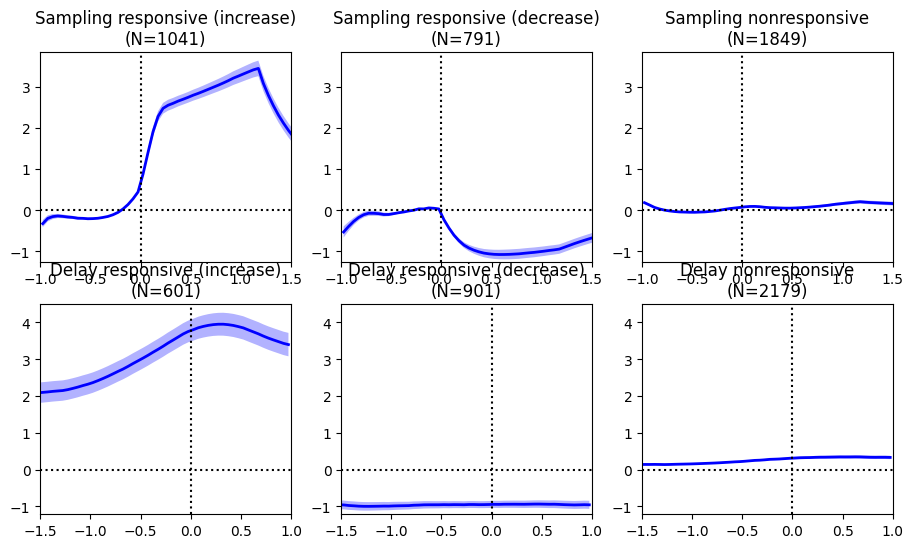

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(11, 6));

t_align_T = t
t_align_D = t - (t[-1] - 1 + 0.025)

y_low, y_high = 0, 0
mat = psths[is_taste_responsive & (taste_change == 1), :]
mean_ = mat.mean(axis=0)
std_ = mat.std(axis=0) / np.sqrt(mat.shape[0])
patch = plt.Polygon(
    [[t_align_T[i], mean_[i] - std_[i]] for i in range(len(t))] + [[t_align_T[i], mean_[i] + std_[i]] 
                                                                   for i in range(len(t))[::-1]],
    facecolor='b',
    edgecolor=None,
    alpha=0.3
)
axes[0, 0].add_patch(patch);
axes[0, 0].plot(t_align_T, mean_, color='b', linewidth=2);
axes[0, 0].axvline(0, color='k', linestyle=':');
axes[0, 0].axhline(0, color='k', linestyle=':');
axes[0, 0].set_title('Sampling responsive (increase)\n(N={})'.format(mat.shape[0]));
axes[0, 0].set_xlim([-1, 1.5]);
y_low, y_high = min(y_low, axes[0, 0].get_ylim()[0]), max(y_high, axes[0, 0].get_ylim()[1])
    
mat = psths[is_taste_responsive & (taste_change == 0), :]
mean_ = mat.mean(axis=0)
std_ = mat.std(axis=0) / np.sqrt(mat.shape[0])
patch = plt.Polygon(
    [[t_align_T[i], mean_[i] - std_[i]] for i in range(len(t))] + [[t_align_T[i], mean_[i] + std_[i]] 
                                                                   for i in range(len(t))[::-1]],
    facecolor='b',
    edgecolor=None,
    alpha=0.3
)
axes[0, 1].add_patch(patch);
axes[0, 1].plot(t_align_T, mean_, color='b', linewidth=2);
axes[0, 1].axvline(0, color='k', linestyle=':');
axes[0, 1].axhline(0, color='k', linestyle=':');
axes[0, 1].set_title('Sampling responsive (decrease)\n(N={})'.format(mat.shape[0]));
axes[0, 1].set_xlim([-1, 1.5]);
y_low, y_high = min(y_low, axes[0, 1].get_ylim()[0]), max(y_high, axes[0, 1].get_ylim()[1])
    
mat = psths[~is_taste_responsive, :]
mean_ = mat.mean(axis=0)
std_ = mat.std(axis=0) / np.sqrt(mat.shape[0])
patch = plt.Polygon(
    [[t_align_T[i], mean_[i] - std_[i]] for i in range(len(t))] + [[t_align_T[i], mean_[i] + std_[i]] 
                                                                   for i in range(len(t))[::-1]],
    facecolor='b',
    edgecolor=None,
    alpha=0.3
)
axes[0, 2].add_patch(patch);
axes[0, 2].plot(t_align_T, mean_, color='b', linewidth=2);
axes[0, 2].axvline(0, color='k', linestyle=':');
axes[0, 2].axhline(0, color='k', linestyle=':');
axes[0, 2].set_title('Sampling nonresponsive\n(N={})'.format(mat.shape[0]));
axes[0, 2].set_xlim([-1, 1.5]);
y_low, y_high = min(y_low, axes[0, 2].get_ylim()[0]), max(y_high, axes[0, 2].get_ylim()[1])

for i in range(3): axes[0, i].set_ylim([y_low, y_high]);
    
y_low, y_high = 0, 0
mat = psths[is_delay_responsive & (delay_change == 1), :]
mean_ = mat.mean(axis=0)
std_ = mat.std(axis=0) / np.sqrt(mat.shape[0])
patch = plt.Polygon(
    [[t_align_D[i], mean_[i] - std_[i]] for i in range(len(t))] + [[t_align_D[i], mean_[i] + std_[i]] 
                                                                   for i in range(len(t))[::-1]],
    facecolor='b',
    edgecolor=None,
    alpha=0.3
)
axes[1, 0].add_patch(patch);
axes[1, 0].plot(t_align_D, mean_, color='b', linewidth=2);
axes[1, 0].axvline(0, color='k', linestyle=':');
axes[1, 0].axhline(0, color='k', linestyle=':');
axes[1, 0].set_title('Delay responsive (increase)\n(N={})'.format(mat.shape[0]));
axes[1, 0].set_xlim([-1.5, 1]);
y_low, y_high = min(y_low, axes[1, 0].get_ylim()[0]), max(y_high, axes[1, 0].get_ylim()[1])
    
mat = psths[is_delay_responsive & (delay_change == 0), :]
mean_ = mat.mean(axis=0)
std_ = mat.std(axis=0) / np.sqrt(mat.shape[0])
patch = plt.Polygon(
    [[t_align_D[i], mean_[i] - std_[i]] for i in range(len(t))] + [[t_align_D[i], mean_[i] + std_[i]] 
                                                                   for i in range(len(t))[::-1]],
    facecolor='b',
    edgecolor=None,
    alpha=0.3
)
axes[1, 1].add_patch(patch);
axes[1, 1].plot(t_align_D, mean_, color='b', linewidth=2);
axes[1, 1].axvline(0, color='k', linestyle=':');
axes[1, 1].axhline(0, color='k', linestyle=':');
axes[1, 1].set_title('Delay responsive (decrease)\n(N={})'.format(mat.shape[0]));
axes[1, 1].set_xlim([-1.5, 1]);
y_low, y_high = min(y_low, axes[1, 1].get_ylim()[0]), max(y_high, axes[1, 1].get_ylim()[1])

mat = psths[~is_delay_responsive, :]
mean_ = mat.mean(axis=0)
std_ = mat.std(axis=0) / np.sqrt(mat.shape[0])
patch = plt.Polygon(
    [[t_align_D[i], mean_[i] - std_[i]] for i in range(len(t))] + [[t_align_D[i], mean_[i] + std_[i]] 
                                                                   for i in range(len(t))[::-1]],
    facecolor='b',
    edgecolor=None,
    alpha=0.3
)
axes[1, 2].add_patch(patch);
axes[1, 2].plot(t_align_D, mean_, color='b', linewidth=2);
axes[1, 2].axvline(0, color='k', linestyle=':');
axes[1, 2].axhline(0, color='k', linestyle=':');
axes[1, 2].set_title('Delay nonresponsive\n(N={})'.format(mat.shape[0]));
axes[1, 2].set_xlim([-1.5, 1]);
y_low, y_high = min(y_low, axes[1, 2].get_ylim()[0]), max(y_high, axes[1, 2].get_ylim()[1])

for i in range(3): axes[1, i].set_ylim([y_low, y_high]);

# Figure S2A-B
# plt.savefig('plots/model/responsive_units.pdf');

### Single unit response profiles

In [17]:
labels_over_time = []
for i_t in range(len(t_downsample)):
    labels = []
    for i_model in included_sessions:
        labels += output_noise['all_labels'][i_model][i_t]
    labels_over_time.append(labels)
n_neurons_all = np.sum([all_models[i].network_size for i in included_sessions])
is_linear = np.full(n_neurons_all, False)
is_perception = np.full(n_neurons_all, False)
is_choice = np.full(n_neurons_all, False)
for i_neuron in range(n_neurons_all):
    label_seq = [labels_over_time[i_t][i_neuron] for i_t in range(len(labels_over_time))]
    is_linear[i_neuron] = 'Linear' in label_seq
    is_perception[i_neuron] = 'Step (Perception)' in label_seq
    is_choice[i_neuron] = 'Step (Choice)' in label_seq
N_coding = (is_linear | is_perception | is_choice).sum()
den = n_neurons_all

0.1488725889703885


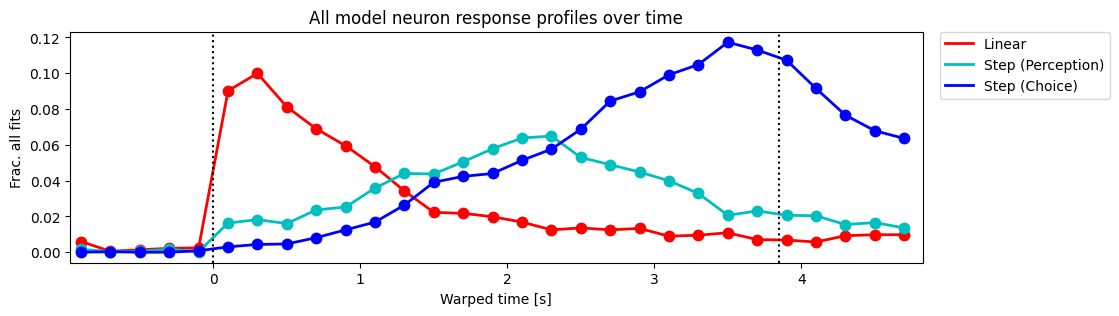

In [18]:
fig, ax = plt.subplots(figsize=(11, 3));
n_lin = np.array([sum([label == 'Linear' for label in labels]) for labels in labels_over_time])
ax.plot(t_downsample, n_lin / den, '.r', markersize=15);
p1, = ax.plot(t_downsample, n_lin / den, 'r', linewidth=2);
n_perc = np.array([sum([label == 'Step (Perception)' for label in labels]) for labels in labels_over_time])
ax.plot(t_downsample, n_perc / den, '.c', markersize=15);
p2, = ax.plot(t_downsample, n_perc / den, 'c', linewidth=2);
n_choice = np.array([sum([label == 'Step (Choice)' for label in labels]) for labels in labels_over_time])
ax.plot(t_downsample, n_choice / den, '.b', markersize=15);
p3, = ax.plot(t_downsample, n_choice / den, 'b', linewidth=2);
ax.set_xlim([t[0], t[-1]]);
ax.set_xlabel('Warped time [s]');
ax.set_ylabel('Frac. all fits');
ax.axvline(0, color='k', linestyle=':');
ax.axvline(t_D, color='k', linestyle=':');
ax.legend([p1, p2, p3], ['Linear', 'Step (Perception)', 'Step (Choice)'], 
          bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.);
ax.set_title('All model neuron response profiles over time');

# Figure 6C
# plt.savefig('plots/model/model_response_profiles_over_time.pdf');

print(((n_lin + n_perc + n_choice) / n_neurons_all).max())

In [19]:
print('Breakdown of all neurons ({}):\n'.format(n_neurons_all))
print('    Linear AND Perception AND Choice: {} ({:.1f}%)'.format( 
      (is_linear & is_perception & is_choice).sum(),
        100 * (is_linear & is_perception & is_choice).sum() / n_neurons_all
))
print('    Linear AND Perception AND NOT Choice: {} ({:.1f}%)'.format( 
      (is_linear & is_perception & ~is_choice).sum(),
        100 * (is_linear & is_perception & ~is_choice).sum() / n_neurons_all
))
print('    Linear AND NOT Perception AND Choice: {} ({:.1f}%)'.format( 
      (is_linear & ~is_perception & is_choice).sum(),
        100 * (is_linear & ~is_perception & is_choice).sum() / n_neurons_all
))
print('    Linear AND NOT Perception AND NOT Choice: {} ({:.1f}%)'.format( 
      (is_linear & ~is_perception & ~is_choice).sum(),
        100 * (is_linear & ~is_perception & ~is_choice).sum() / n_neurons_all
))
print('    NOT Linear AND Perception AND Choice: {} ({:.1f}%)'.format( 
      (~is_linear & is_perception & is_choice).sum(),
        100 * (~is_linear & is_perception & is_choice).sum() / n_neurons_all
))
print('    NOT Linear AND Perception AND NOT Choice: {} ({:.1f}%)'.format( 
      (~is_linear & is_perception & ~is_choice).sum(),
        100 * (~is_linear & is_perception & ~is_choice).sum() / n_neurons_all
))
print('    NOT Linear AND NOT Perception AND Choice: {} ({:.1f}%)'.format( 
      (~is_linear & ~is_perception & is_choice).sum(),
        100 * (~is_linear & ~is_perception & is_choice).sum() / n_neurons_all
))
print('    NOT Linear AND NOT Perception AND NOT Choice: {} ({:.1f}%)\n'.format( 
      (~is_linear & ~is_perception & ~is_choice).sum(),
        100 * (~is_linear & ~is_perception & ~is_choice).sum() / n_neurons_all
))
print('    Linear: {} ({:.1f}%)'.format( 
      is_linear.sum(),
        100 * is_linear.sum() / n_neurons_all
))
print('    Perception: {} ({:.1f}%)'.format( 
      is_perception.sum(),
        100 * is_perception.sum() / n_neurons_all
))
print('    Choice: {} ({:.1f}%)\n'.format( 
      is_choice.sum(),
        100 * is_choice.sum() / n_neurons_all
))

Breakdown of all neurons (3681):

    Linear AND Perception AND Choice: 321 (8.7%)
    Linear AND Perception AND NOT Choice: 175 (4.8%)
    Linear AND NOT Perception AND Choice: 167 (4.5%)
    Linear AND NOT Perception AND NOT Choice: 222 (6.0%)
    NOT Linear AND Perception AND Choice: 242 (6.6%)
    NOT Linear AND Perception AND NOT Choice: 249 (6.8%)
    NOT Linear AND NOT Perception AND Choice: 213 (5.8%)
    NOT Linear AND NOT Perception AND NOT Choice: 2092 (56.8%)

    Linear: 885 (24.0%)
    Perception: 987 (26.8%)
    Choice: 943 (25.6%)



In [20]:
is_other = (~is_linear & ~is_perception & ~is_choice)

print('{}/{} ({:.1f}%) Other neurons are taste-responsive'.format(
    (is_other & is_taste_responsive).sum(), is_other.sum(),
    100 * (is_other & is_taste_responsive).sum() / is_other.sum()
))
print('{}/{} ({:.1f}%) Other neurons are taste-selective\n'.format(
    (is_other & is_taste_selective).sum(), is_other.sum(),
    100 * (is_other & is_taste_selective).sum() / is_other.sum()
))

print('{}/{} ({:.1f}%) Other neurons are delay-responsive'.format(
    (is_other & is_delay_responsive).sum(), is_other.sum(),
    100 * (is_other & is_delay_responsive).sum() / is_other.sum()
))
print('{}/{} ({:.1f}%) Other neurons are delay-selective\n'.format(
    (is_other & is_delay_selective).sum(), is_other.sum(),
    100 * (is_other & is_delay_selective).sum() / is_other.sum()
))

print('{}/{} ({:.1f}%) Other neurons are responsive to both'.format(
    (is_other & is_delay_responsive & is_taste_responsive).sum(), is_other.sum(),
    100 * (is_other & is_delay_responsive & is_taste_responsive).sum() / is_other.sum()
))

615/2092 (29.4%) Other neurons are taste-responsive
197/2092 (9.4%) Other neurons are taste-selective

490/2092 (23.4%) Other neurons are delay-responsive
96/2092 (4.6%) Other neurons are delay-selective

359/2092 (17.2%) Other neurons are responsive to both


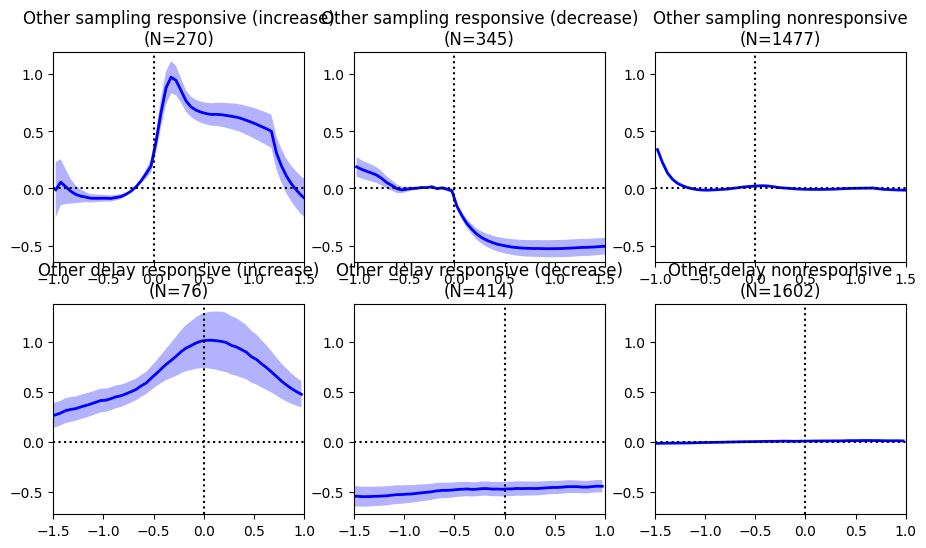

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(11, 6));

t_align_T = t
t_align_D = t - (t[-1] - 1 + 0.025)

y_low, y_high = 0, 0
mat = psths[is_other & is_taste_responsive & (taste_change == 1), :]
mean_ = mat.mean(axis=0)
std_ = mat.std(axis=0) / np.sqrt(mat.shape[0])
patch = plt.Polygon(
    [[t_align_T[i], mean_[i] - std_[i]] for i in range(len(t))] + [[t_align_T[i], mean_[i] + std_[i]] 
                                                                   for i in range(len(t))[::-1]],
    facecolor='b',
    edgecolor=None,
    alpha=0.3
)
axes[0, 0].add_patch(patch);
axes[0, 0].plot(t_align_T, mean_, color='b', linewidth=2);
axes[0, 0].axvline(0, color='k', linestyle=':');
axes[0, 0].axhline(0, color='k', linestyle=':');
axes[0, 0].set_title('Other sampling responsive (increase)\n(N={})'.format(mat.shape[0]));
axes[0, 0].set_xlim([-1, 1.5]);
y_low, y_high = min(y_low, axes[0, 0].get_ylim()[0]), max(y_high, axes[0, 0].get_ylim()[1])
    
mat = psths[is_other & is_taste_responsive & (taste_change == 0), :]
mean_ = mat.mean(axis=0)
std_ = mat.std(axis=0) / np.sqrt(mat.shape[0])
patch = plt.Polygon(
    [[t_align_T[i], mean_[i] - std_[i]] for i in range(len(t))] + [[t_align_T[i], mean_[i] + std_[i]] 
                                                                   for i in range(len(t))[::-1]],
    facecolor='b',
    edgecolor=None,
    alpha=0.3
)
axes[0, 1].add_patch(patch);
axes[0, 1].plot(t_align_T, mean_, color='b', linewidth=2);
axes[0, 1].axvline(0, color='k', linestyle=':');
axes[0, 1].axhline(0, color='k', linestyle=':');
axes[0, 1].set_title('Other sampling responsive (decrease)\n(N={})'.format(mat.shape[0]));
axes[0, 1].set_xlim([-1, 1.5]);
y_low, y_high = min(y_low, axes[0, 1].get_ylim()[0]), max(y_high, axes[0, 1].get_ylim()[1])
    
mat = psths[is_other & ~is_taste_responsive, :]
mean_ = mat.mean(axis=0)
std_ = mat.std(axis=0) / np.sqrt(mat.shape[0])
patch = plt.Polygon(
    [[t_align_T[i], mean_[i] - std_[i]] for i in range(len(t))] + [[t_align_T[i], mean_[i] + std_[i]] 
                                                                   for i in range(len(t))[::-1]],
    facecolor='b',
    edgecolor=None,
    alpha=0.3
)
axes[0, 2].add_patch(patch);
axes[0, 2].plot(t_align_T, mean_, color='b', linewidth=2);
axes[0, 2].axvline(0, color='k', linestyle=':');
axes[0, 2].axhline(0, color='k', linestyle=':');
axes[0, 2].set_title('Other sampling nonresponsive\n(N={})'.format(mat.shape[0]));
axes[0, 2].set_xlim([-1, 1.5]);
y_low, y_high = min(y_low, axes[0, 2].get_ylim()[0]), max(y_high, axes[0, 2].get_ylim()[1])

for i in range(3): axes[0, i].set_ylim([y_low, y_high]);
    
y_low, y_high = 0, 0
mat = psths[is_other & is_delay_responsive & (delay_change == 1), :]
mean_ = mat.mean(axis=0)
std_ = mat.std(axis=0) / np.sqrt(mat.shape[0])
patch = plt.Polygon(
    [[t_align_D[i], mean_[i] - std_[i]] for i in range(len(t))] + [[t_align_D[i], mean_[i] + std_[i]] 
                                                                   for i in range(len(t))[::-1]],
    facecolor='b',
    edgecolor=None,
    alpha=0.3
)
axes[1, 0].add_patch(patch);
axes[1, 0].plot(t_align_D, mean_, color='b', linewidth=2);
axes[1, 0].axvline(0, color='k', linestyle=':');
axes[1, 0].axhline(0, color='k', linestyle=':');
axes[1, 0].set_title('Other delay responsive (increase)\n(N={})'.format(mat.shape[0]));
axes[1, 0].set_xlim([-1.5, 1]);
y_low, y_high = min(y_low, axes[1, 0].get_ylim()[0]), max(y_high, axes[1, 0].get_ylim()[1])
    
mat = psths[is_other & is_delay_responsive & (delay_change == 0), :]
mean_ = mat.mean(axis=0)
std_ = mat.std(axis=0) / np.sqrt(mat.shape[0])
patch = plt.Polygon(
    [[t_align_D[i], mean_[i] - std_[i]] for i in range(len(t))] + [[t_align_D[i], mean_[i] + std_[i]] 
                                                                   for i in range(len(t))[::-1]],
    facecolor='b',
    edgecolor=None,
    alpha=0.3
)
axes[1, 1].add_patch(patch);
axes[1, 1].plot(t_align_D, mean_, color='b', linewidth=2);
axes[1, 1].axvline(0, color='k', linestyle=':');
axes[1, 1].axhline(0, color='k', linestyle=':');
axes[1, 1].set_title('Other delay responsive (decrease)\n(N={})'.format(mat.shape[0]));
axes[1, 1].set_xlim([-1.5, 1]);
y_low, y_high = min(y_low, axes[1, 1].get_ylim()[0]), max(y_high, axes[1, 1].get_ylim()[1])

mat = psths[is_other & ~is_delay_responsive, :]
mean_ = mat.mean(axis=0)
std_ = mat.std(axis=0) / np.sqrt(mat.shape[0])
patch = plt.Polygon(
    [[t_align_D[i], mean_[i] - std_[i]] for i in range(len(t))] + [[t_align_D[i], mean_[i] + std_[i]] 
                                                                   for i in range(len(t))[::-1]],
    facecolor='b',
    edgecolor=None,
    alpha=0.3
)
axes[1, 2].add_patch(patch);
axes[1, 2].plot(t_align_D, mean_, color='b', linewidth=2);
axes[1, 2].axvline(0, color='k', linestyle=':');
axes[1, 2].axhline(0, color='k', linestyle=':');
axes[1, 2].set_title('Other delay nonresponsive\n(N={})'.format(mat.shape[0]));
axes[1, 2].set_xlim([-1.5, 1]);
y_low, y_high = min(y_low, axes[1, 2].get_ylim()[0]), max(y_high, axes[1, 2].get_ylim()[1])

for i in range(3): axes[1, i].set_ylim([y_low, y_high]);

# Figure S2C-D
# plt.savefig('plots/model/responsive_other_units.pdf');

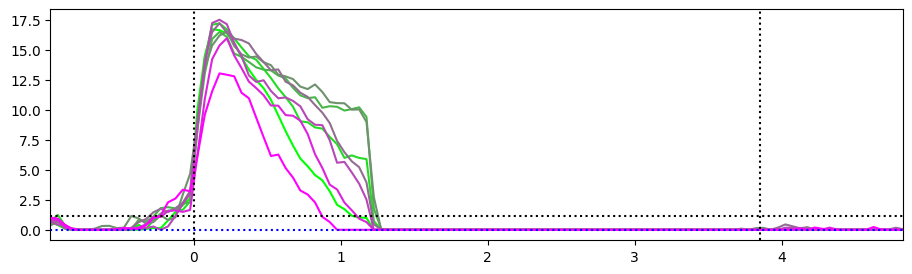

In [22]:
# example Other neuron that is task-responsive

ind = 0
inds = []
for i_session in res:
    for i_neuron in res[i_session]:
        if is_delay_responsive[ind] and is_taste_responsive[ind] and is_other[ind]:
            inds.append((i_session, i_neuron))
        ind += 1

i_session, i_neuron = inds[13]

fig, ax = plt.subplots(figsize=(11, 3));
psths = output_noise['all_psths_correct'][i_session][i_neuron]
for i_stim in range(psths.shape[0]):
    ax.plot(t, psths[i_stim, :], color=colors[i_stim]);
ax.axvline(0, color='k', linestyle=':');
ax.axvline(t[-1] - 1 + 0.025, color='k', linestyle=':');
ax.axhline(res[i_session][i_neuron]['fr_baseline'].mean(), color='k', linestyle=':');
ax.axhline(res[i_session][i_neuron]['fr_delay'].mean(), color='b', linestyle=':');
ax.set_xlim([t[0], t[-1]]);

# Figure S3B
# plt.savefig('plots/model/example_taste_selective_other_2.pdf');

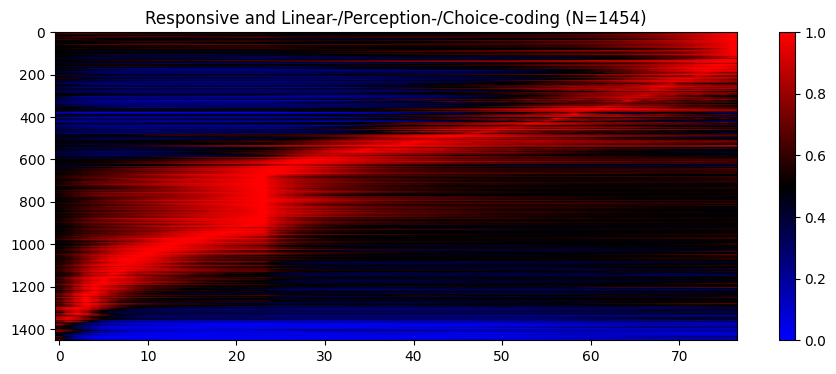

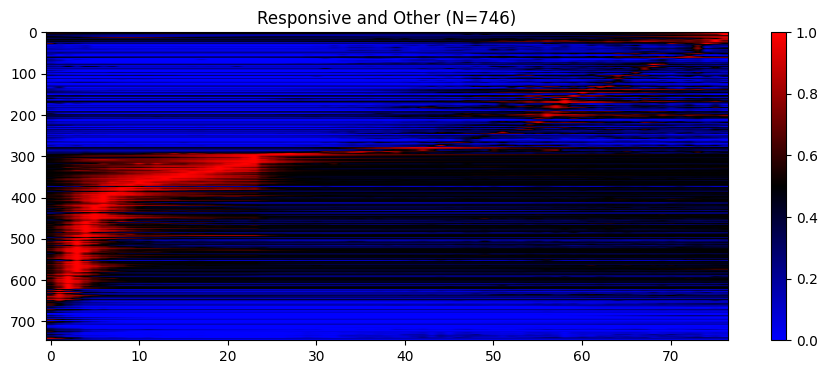

In [23]:
# responsive neuron patterns

ind = 0
all_psths, all_other_psths = [], []
for i_session in res:
    for i_neuron in res[i_session]:
        if is_taste_responsive[ind] or is_delay_responsive[ind]:            
            # relative to baseline
            psth = res[i_session][i_neuron]['psth'] - res[i_session][i_neuron]['fr_baseline'].mean() 
            # focus on inter-event interval
            psth = psth[20:-20]
            # normalize to max
            psth = psth / np.max(np.abs(psth))            
            if is_other[ind]:
                all_other_psths.append(psth)
            else:
                all_psths.append(psth)
        ind += 1
        
def sort_heatmap(heatmap):
    max_vals = np.array([heatmap[i, np.argmax(np.abs(heatmap[i, :]))] for i in range(heatmap.shape[0])])
    tmax = np.array([np.argmax(heatmap[i, :]) for i in range(heatmap.shape[0])])
    heatmap = heatmap[np.argsort(tmax)[::-1], :]
    return heatmap

cmap = LinearSegmentedColormap.from_list('my_cmap', [(0, [0, 0, 1]), (0.5, [0, 0, 0]), (1, [1, 0, 0])])

fig, ax = plt.subplots(figsize=(11, 4));
im = ax.imshow((sort_heatmap(np.array(all_psths)) + 1) / 2, cmap=cmap, aspect='auto');
ax.set_title('Responsive and Linear-/Perception-/Choice-coding (N={})'.format(len(all_psths)));
plt.colorbar(im, ax=ax);

# Figure S3A
# plt.savefig('plots/model/responsive_coding_heatmap.pdf');

fig, ax = plt.subplots(figsize=(11, 4));
im = ax.imshow((sort_heatmap(np.array(all_other_psths)) + 1) / 2, cmap=cmap, aspect='auto');
ax.set_title('Responsive and Other (N={})'.format(len(all_other_psths)));
plt.colorbar(im, ax=ax);

# Figure S3A
# plt.savefig('plots/model/responsive_other_heatmap.pdf');

# # for time scale
# fig, ax = plt.subplots(figsize=(11, 3));
# ax.axvline(0, color='k');
# ax.axvline(t[-1] - 1 + 0.025, color='k');
# # plt.savefig('plots/model/responsive_other_heatmap_scale.pdf');

### Ablation experiments

In [24]:
# create 'label_data' for ablation experiments

label_data = []
for labels_over_time_model in output_noise['all_labels']:
    ind_lin = []
    ind_lin_ex = []
    ind_perception = []
    ind_perception_ex = []
    ind_choice = []
    ind_choice_ex = []
    ind_none = []
    ind_all = []
    ind_ex = []
    ind_multi = []
    n_neurons = len(labels_over_time_model[0])
    for i_neuron in range(n_neurons):
        label_over_time = [labels_over_time_model[i_t][i_neuron] for i_t in range(len(labels_over_time_model))]
        is_linear = 'Linear' in label_over_time
        is_perception = 'Step (Perception)' in label_over_time
        is_choice = 'Step (Choice)' in label_over_time
        if is_linear: 
            ind_lin.append(i_neuron)
        if is_linear and all([not is_perception, not is_choice]): 
            ind_lin_ex.append(i_neuron)
            ind_ex.append(i_neuron)
        if is_perception: 
            ind_perception.append(i_neuron)
        if is_perception and all([not is_linear, not is_choice]): 
            ind_perception_ex.append(i_neuron)
            ind_ex.append(i_neuron)
        if is_choice: 
            ind_choice.append(i_neuron)
        if is_choice and all([not is_linear, not is_perception]): 
            ind_choice_ex.append(i_neuron)
            ind_ex.append(i_neuron)
        if all([not is_linear, not is_perception, not is_choice]): 
            ind_none.append(i_neuron)
        if all([is_linear, is_perception, is_choice]):
            ind_all.append(i_neuron)
        if np.sum([is_linear, is_perception, is_choice]) > 1:
            ind_multi.append(i_neuron)
    label_data.append({
        'ind_lin': ind_lin.copy(),
        'ind_lin_ex': ind_lin_ex.copy(),
        'ind_perception': ind_perception.copy(),
        'ind_perception_ex': ind_perception_ex.copy(),
        'ind_choice': ind_choice.copy(),
        'ind_choice_ex': ind_choice_ex.copy(),
        'ind_none': ind_none.copy(),
        'ind_all': ind_all.copy(),
        'ind_ex': ind_ex.copy(),
        'ind_multi': ind_multi.copy()
    })

### Ablate 'Other'

In [25]:
try:
    with open('data/model/output_tailored_noise_ablate_none.pkl', 'rb') as file:
        output_noise_ablate_none = pickle.load(file)
        file.close()
except:
    output_noise_ablate_none = multi_model_simulation(
        all_models, 
        inputs, 
        unique_stims, 
        t_decision_window,
        n_trials_per_stim=n_trials_per_stim, 
        sigma=inputs_sigma,
        silenced='ind_none',
        label_data=label_data, 
        responses_over_time=False,
        fit_options=None,
        inds_L=None, 
        inds_R=None,
        responses_beginning_end=False,
        window_beginning=None,
        window_end=None)
    with open('data/model/output_tailored_noise_ablate_none.pkl', 'wb') as file:
        pickle.dump(output_noise_ablate_none, file)
        file.close()

### Ablate 'Linear'

In [26]:
try:
    with open('data/model/output_tailored_noise_ablate_linear.pkl', 'rb') as file:
        output_noise_ablate_linear = pickle.load(file)
        file.close()
except:
    output_noise_ablate_linear = multi_model_simulation(
        all_models, 
        inputs, 
        unique_stims, 
        t_decision_window,
        n_trials_per_stim=n_trials_per_stim, 
        sigma=inputs_sigma,
        silenced='ind_lin',
        label_data=label_data, 
        responses_over_time=False,
        fit_options=None,
        inds_L=None, 
        inds_R=None,
        responses_beginning_end=False,
        window_beginning=None,
        window_end=None)
    with open('data/model/output_tailored_noise_ablate_linear.pkl', 'wb') as file:
        pickle.dump(output_noise_ablate_linear, file)
        file.close()

### Ablate 'Step-Perception'

In [27]:
try:
    with open('data/model/output_tailored_noise_ablate_perception.pkl', 'rb') as file:
        output_noise_ablate_perception = pickle.load(file)
        file.close()
except:
    output_noise_ablate_perception = multi_model_simulation(
        all_models, 
        inputs, 
        unique_stims, 
        t_decision_window,
        n_trials_per_stim=n_trials_per_stim, 
        sigma=inputs_sigma,
        silenced='ind_perception',
        label_data=label_data, 
        responses_over_time=False,
        fit_options=None,
        inds_L=None, 
        inds_R=None,
        responses_beginning_end=False,
        window_beginning=None,
        window_end=None)
    with open('data/model/output_tailored_noise_ablate_perception.pkl', 'wb') as file:
        pickle.dump(output_noise_ablate_perception, file)
        file.close()

### Ablate 'Step-Choice'

In [28]:
try:
    with open('data/model/output_tailored_noise_ablate_choice.pkl', 'rb') as file:
        output_noise_ablate_choice = pickle.load(file)
        file.close()
except:
    output_noise_ablate_choice = multi_model_simulation(
        all_models, 
        inputs, 
        unique_stims, 
        t_decision_window,
        n_trials_per_stim=n_trials_per_stim, 
        sigma=inputs_sigma,
        silenced='ind_choice',
        label_data=label_data, 
        responses_over_time=False,
        fit_options=None,
        inds_L=None, 
        inds_R=None,
        responses_beginning_end=False,
        window_beginning=None,
        window_end=None)
    with open('data/model/output_tailored_noise_ablate_choice.pkl', 'wb') as file:
        pickle.dump(output_noise_ablate_choice, file)
        file.close()

### Stats

In [29]:
data = [
    ([output_noise['all_accuracies'][i] for i in included_sessions], 'control'),
    ([output_noise_ablate_linear['all_accuracies'][i] for i in included_sessions], 'linear'),
    ([output_noise_ablate_perception['all_accuracies'][i] for i in included_sessions], 'perception'),
    ([output_noise_ablate_choice['all_accuracies'][i] for i in included_sessions], 'choice'),
    ([output_noise_ablate_none['all_accuracies'][i] for i in included_sessions], 'other')
]

n_subjects = n_sessions
n_conditions = len(data)
subject = [i for i in range(n_subjects)] * n_conditions
condition, measurement = [], []
for i in range(n_conditions):
    condition += ['{}'.format(i)] * n_subjects
    measurement += data[i][0]
df = pd.DataFrame({
    'subject': subject,
    'condition': condition,
    'measurement': measurement
})

# Perform repeated measures ANOVA
rm_anova = AnovaRM(df, 'measurement', 'subject', within=['condition'])
results = rm_anova.fit()

# Print the results
display(results.anova_table)

# post-hoc tests
correction = scipy.special.comb(n_conditions, 2) # bonferroni correction for number of paired tests

print('\nPost-hoc tests (Bonferroni-adjusted p-values):\n')
for i in range(n_conditions - 1):
    for j in range(i + 1, n_conditions):
        x1, label1 = data[i]
        x2, label2 = data[j]
        print('    {} vs. {}: p = {:.4e}'.format(label1, label2, correction * scipy.stats.ttest_rel(x1, x2)[1]))

,F Value,Num DF,Den DF,Pr > F
condition,116.51567,4.0,88.0,2.633677e-34



Post-hoc tests (Bonferroni-adjusted p-values):

    control vs. linear: p = 6.5079e-16
    control vs. perception: p = 9.2251e-11
    control vs. choice: p = 6.2675e-13
    control vs. other: p = 1.9664e-01
    linear vs. perception: p = 2.0646e+00
    linear vs. choice: p = 9.8523e+00
    linear vs. other: p = 1.9956e-10
    perception vs. choice: p = 2.5047e+00
    perception vs. other: p = 8.6255e-08
    choice vs. other: p = 1.2777e-08


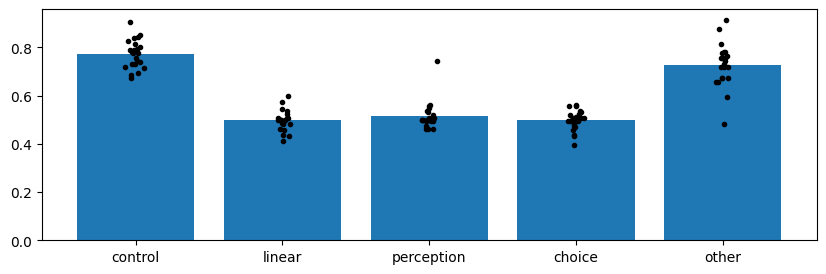

In [30]:
# plot accuracies

fig, ax = plt.subplots(figsize=(10, 3));
ax.bar([data[i][1] for i in range(len(data))], [np.mean(data[i][0]) for i in range(len(data))]);
for i in range(len(data)):
    ax.plot(i + 0.025 * np.random.normal(size=len(data[i][0])), data[i][0], '.k');

# Figure 7F
# plt.savefig('plots/model/ablation_accuracies.pdf');

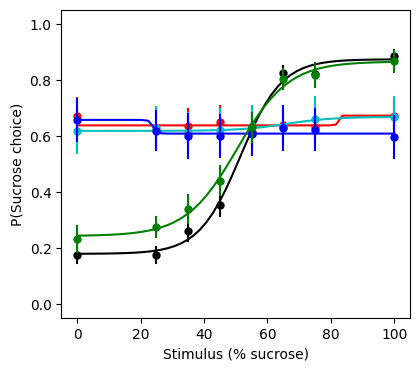

In [31]:
# plot psychometrics

def plot_psychometric(all_p_left, color):
    p_left_mat = np.empty([0, n_stims])
    for p_left in all_p_left:
        p_left_mat = np.vstack([p_left_mat, p_left])
    ave_p_left = p_left_mat.mean(axis=0)
    std_p_left = p_left_mat.std(axis=0) / np.sqrt(p_left_mat.shape[0])
    psycho_res = fit_psychometric(unique_stims, ave_p_left)
    ax.plot(psycho_res['x'], psycho_res['y'], color);
    for i_stim, stim in enumerate(unique_stims):
        ax.plot([stim, stim], [ave_p_left[i_stim] - std_p_left[i_stim], ave_p_left[i_stim] + std_p_left[i_stim]], color);
        ax.plot(stim, ave_p_left[i_stim], '.', color=color, markersize=10);
        
fig, ax = plt.subplots(figsize=(4.5, 4));
plot_psychometric([output_noise['all_p_left'][i] for i in included_sessions], 'k')
plot_psychometric([output_noise_ablate_linear['all_p_left'][i] for i in included_sessions], 'r')
plot_psychometric([output_noise_ablate_perception['all_p_left'][i] for i in included_sessions], 'c')
plot_psychometric([output_noise_ablate_choice['all_p_left'][i] for i in included_sessions], 'b')
plot_psychometric([output_noise_ablate_none['all_p_left'][i] for i in included_sessions], 'g')
ax.set_ylim([-0.05, 1.05]);
ax.set_xlabel('Stimulus (% sucrose)');
ax.set_ylabel('P(Sucrose choice)');

# Figure 7F
# plt.savefig('plots/model/ablation_psychometrics.pdf');

In [32]:
p_left_control = np.array([output_noise['all_p_left'][i] for i in included_sessions]).mean(axis=0)
p_left_other = np.array([output_noise_ablate_none['all_p_left'][i] for i in included_sessions]).mean(axis=0)
p_left_linear = np.array([output_noise_ablate_linear['all_p_left'][i] for i in included_sessions]).mean(axis=0)
p_left_perception = np.array([output_noise_ablate_perception['all_p_left'][i] for i in included_sessions]).mean(axis=0)
p_left_choice = np.array([output_noise_ablate_choice['all_p_left'][i] for i in included_sessions]).mean(axis=0)

correction = scipy.special.comb(n_conditions, 2)
# correction = 4

# control vs. ablated other
Y = [p_left_control, p_left_other]
res = psychometric_comparison_test(unique_stims, Y)
print('Control vs. ablated other, F = {:.4f}, p = {:.4f}, corrected p = {:.4f}'.format(
    res['F'], res['p'], correction * res['p']
))

# control vs. ablated linear
Y = [p_left_control, p_left_linear]
res = psychometric_comparison_test(unique_stims, Y)
print('Control vs. ablated linear, F = {:.4f}, p = {:.4f}, corrected p = {:.4f}'.format(
    res['F'], res['p'], correction * res['p']
))

# control vs. ablated perception
Y = [p_left_control, p_left_perception]
res = psychometric_comparison_test(unique_stims, Y)
print('Control vs. ablated perception, F = {:.4f}, p = {:.4f}, corrected p = {:.4f}'.format(
    res['F'], res['p'], correction * res['p']
))

# control vs. ablated choice
Y = [p_left_control, p_left_choice]
res = psychometric_comparison_test(unique_stims, Y)
print('Control vs. ablated choice, F = {:.4f}, p = {:.4f}, corrected p = {:.4f}'.format(
    res['F'], res['p'], correction * res['p']
))

Control vs. ablated other, F = 5.1703, p = 0.0235, corrected p = 0.2351
Control vs. ablated linear, F = 139.6094, p = 0.0000, corrected p = 0.0000
Control vs. ablated perception, F = 183.1619, p = 0.0000, corrected p = 0.0000
Control vs. ablated choice, F = 174.4806, p = 0.0000, corrected p = 0.0000


### dPCA

In [45]:
filter_models = True # filter out models that do not have at least 2 trials per choice across all ablation conditions
                     # this is done to improve the linear prediction of missing trial types

outputs = {
    'baseline': output_noise,
    'none': output_noise_ablate_none,
    'linear': output_noise_ablate_linear,
    'perception': output_noise_ablate_perception,
    'choice': output_noise_ablate_choice
}
conditions = outputs.keys()

# filtering criteria
good_model_inds = []
for i_model in included_sessions:
    is_good = True
    if filter_models:
        for condition in conditions:
            y_choice = outputs[condition]['y_lefts'][i_model]
            if (y_choice.sum() <= 1) or (y_choice.sum() >= len(y_choice) - 1):
                is_good = False
                break
    if is_good:
        good_model_inds.append(i_model)
if filter_models:
    print('{}/{} models passed.'.format(len(good_model_inds), len(included_sessions)))
else:
    print('All models included.')
file_name = 'filtered' if filter_models else 'all' 

try:
    
    with open('data/model/dPCA_{}_sessions_results.pkl'.format(file_name), 'rb') as file:
        dPCA_results = pickle.load(file)
        file.close()
        
except:
    
    dPCA_results = {}

    for condition in conditions:

        # get maximum number of trials for any parameter combination across sessions
        max_num_trials = 0
        n_neurons_pseudo = 0
        flagged_models = []
        for i_model in good_model_inds:
            X = outputs[condition]['Xs'][i_model]
            y_stim = outputs[condition]['y_stims'][i_model]
            y_choice = outputs[condition]['y_lefts'][i_model]
            n_neurons_pseudo += X.shape[1]
            for stim in unique_stims:
                for choice in [0, 1]:
                    n = ((y_stim == stim) & (y_choice == choice)).sum()
                    if (n == 0) and (i_model not in flagged_models):
                        flagged_models.append(i_model)
                    max_num_trials = max(max_num_trials, n)

        # assemble pseudo-population trial-by-trial tensor
        # X_pseudo: (trials x neurons x stimuli x decisions x time)
        X_pseudo = np.full([max_num_trials, n_neurons_pseudo, len(unique_stims), 2, len(t)], np.nan)
        n_neurons_cumul = 0
        for i_model in good_model_inds:
            X = outputs[condition]['Xs'][i_model]
            y_stim = outputs[condition]['y_stims'][i_model]
            y_choice = outputs[condition]['y_lefts'][i_model]
            n_neurons = X.shape[1]
            ###----------------------------------------------------------------------------------------------------
            if i_model in flagged_models:
                ### issue: some data are missing for this session
                ### workaround: fit a simple linear model to existing data and use it to predict the missing parts
                predictors = np.vstack([
                    y_stim.reshape([1, -1]),
                    y_choice.reshape([1, -1]),
                    (y_stim * y_choice).reshape([1, -1]),
                    np.ones([1, X.shape[0]])
                ])
                betas = [[scipy.linalg.pinv(predictors @ predictors.T) @ predictors @ X[:, i_n, i_t].reshape([-1, 1])
                          for i_t in range(len(t))] for i_n in range(n_neurons)]
            ###-----------------------------------------------------------------------------------------------------
            for i_stim, stim in enumerate(unique_stims):
                for i_choice, choice in enumerate([0, 1]):
                    trial_mask = (y_stim == stim) & (y_choice == choice)
                    n_trials = trial_mask.sum()
                    if n_trials == 0:
                        ### use the linear model's prediction ------------------------------------------------------
                        for i_n in range(n_neurons):
                            for i_t in range(len(t)):
                                r = max((betas[i_n][i_t].flatten() * np.array([stim, choice, stim * choice, 1])).sum(), 0)
                                X_pseudo[:2, n_neurons_cumul + i_n, i_stim, i_choice, i_t] = np.array([r, r])
                        ### ----------------------------------------------------------------------------------------
                    elif n_trials == 1:
                        X_pseudo[:2, n_neurons_cumul:(n_neurons_cumul + n_neurons), i_stim, i_choice, :] = \
                            np.concatenate([
                            X[trial_mask, :, :].reshape([1, n_neurons, len(t)]),
                            X[trial_mask, :, :].reshape([1, n_neurons, len(t)])],
                            axis=0)
                    else:
                        X_pseudo[:n_trials, n_neurons_cumul:(n_neurons_cumul + n_neurons), i_stim, i_choice, :] = \
                            X[trial_mask, :, :]
            n_neurons_cumul += n_neurons

        # get the pseudo-population trial-averaged (PSTH) tensor
        X_pseudo_psth = np.nanmean(X_pseudo, axis=0)

        # do the dPCA
        dpca = dPCA.dPCA(labels='sdt', regularizer='auto', 
                         join={'st': ['s', 'st'], 'dt': ['d', 'dt'], 'sdt': ['sd', 'sdt']})
        dpca.protect = ['t']
        Z = dpca.fit_transform(X_pseudo_psth, X_pseudo)

        dPCA_results[condition] = {'X_pseudo': X_pseudo, 'X_pseudo_psth': X_pseudo_psth, 'dpca': dpca, 'Z': Z}
        
    with open('data/model/dPCA_{}_sessions_results.pkl'.format(file_name), 'wb') as file:
        pickle.dump(dPCA_results, file)
        file.close()

14/23 models passed.


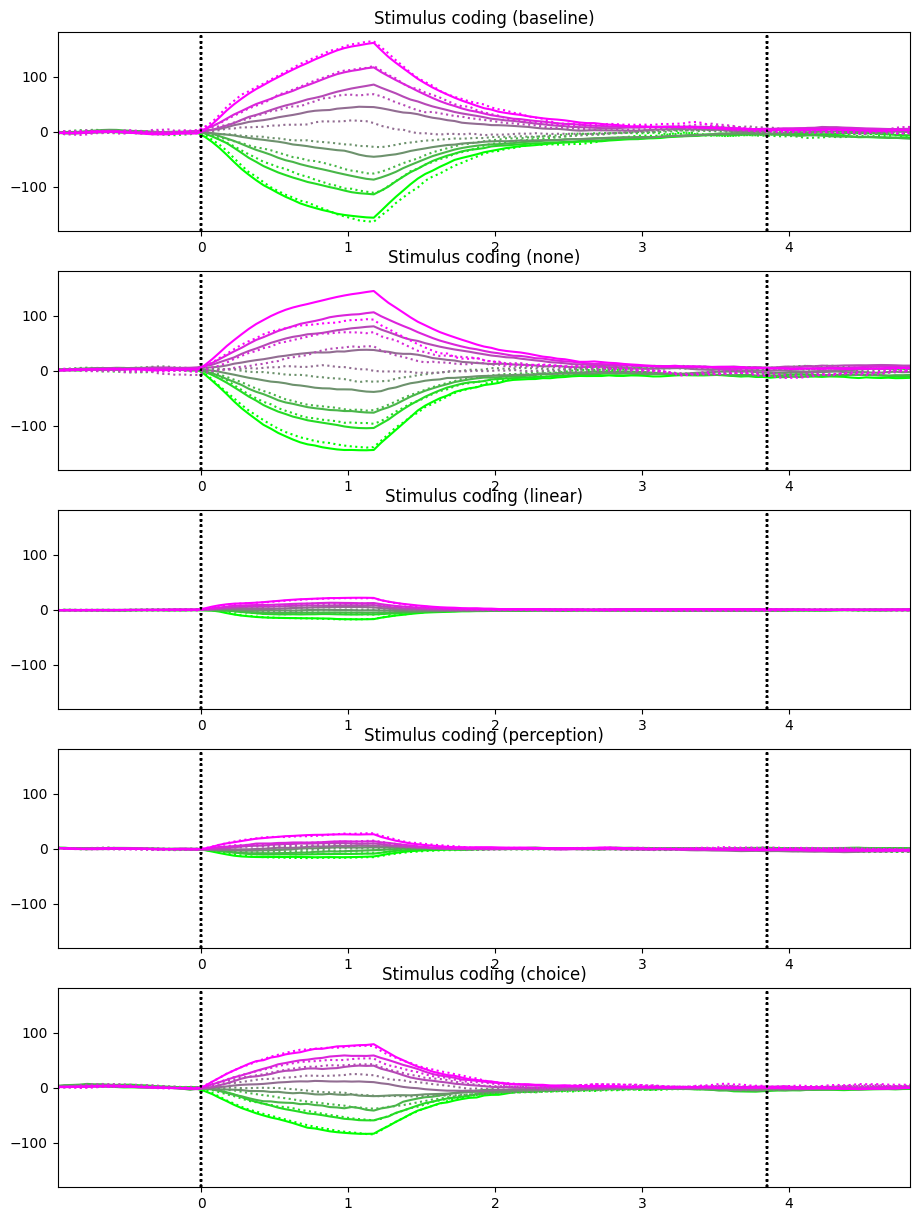

In [46]:
fig, axes = plt.subplots(len(conditions), 1, figsize=(11, 3 * len(conditions)));
y_limits = []
max_stim_projections = []
for i_condition, condition in enumerate(conditions):
    temp = []
    for i_stim, stim in enumerate(unique_stims):
        for i_choice, choice in enumerate([0, 1]):
            style = '-' if (((stim < 50) and (choice == 0)) or ((stim > 50) and (choice == 1))) else ':'
            v = dPCA_results['baseline']['dpca'].D['st'][:, 0]
            X_tensor = dPCA_results[condition]['X_pseudo_psth']
            X_tilde = X_tensor.reshape([X_tensor.shape[0], -1])
            X_tilde -= X_tilde.mean(axis=1).reshape([-1, 1])
            X_tensor = X_tilde.reshape(X_tensor.shape)
            X = X_tensor[:, i_stim, i_choice, :]   
            y = [(v * X[:, k]).sum() for k in range(len(t))]
            temp.append(np.mean(np.abs(y)))
            axes[i_condition].plot(t, y, color=colors[i_stim, :], linestyle=style);
            axes[i_condition].axvline(0, color='k', linestyle=':');
            axes[i_condition].axvline(t_D, color='k', linestyle=':');
            axes[i_condition].set_title('Stimulus coding ({})'.format(condition));
    y_limits.append(axes[i_condition].get_ylim())
    max_stim_projections.append(temp)
global_limit = np.max([np.max(np.abs(lims)) for lims in y_limits])
for ax in axes:
    ax.set_xlim([t[0], t[-1]]);
    ax.set_ylim([-global_limit, global_limit]);
    
# Figure 6A, 7A-D
# plt.savefig('plots/model/dPCA_stimulus_coding.pdf');

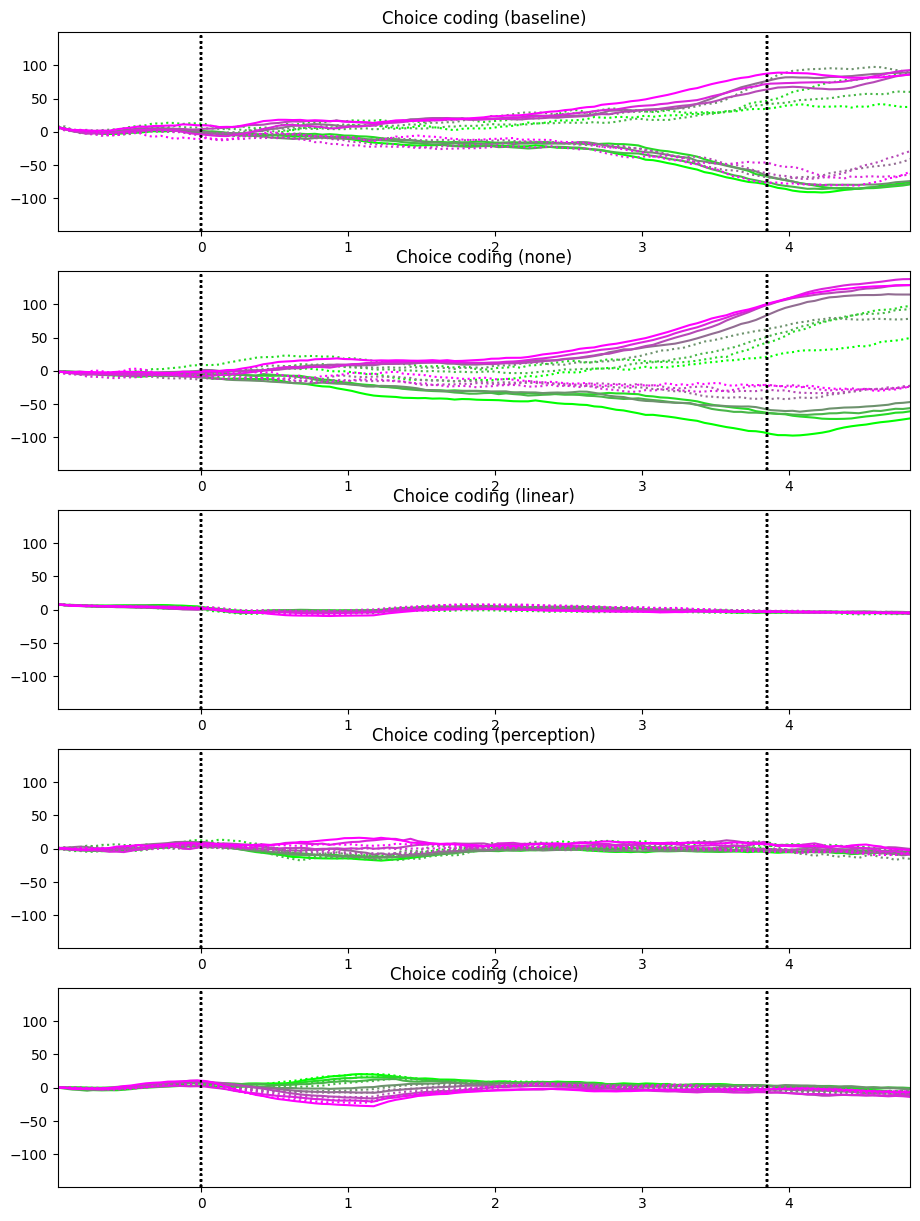

In [47]:
fig, axes = plt.subplots(len(conditions), 1, figsize=(11, 3 * len(conditions)));
y_limits = []
max_choice_projections = []
for i_condition, condition in enumerate(conditions):
    temp = []
    for i_stim, stim in enumerate(unique_stims):
        for i_choice, choice in enumerate([0, 1]):
            style = '-' if (((stim < 50) and (choice == 0)) or ((stim > 50) and (choice == 1))) else ':'
            v = dPCA_results['baseline']['dpca'].D['dt'][:, 0]
            X_tensor = dPCA_results[condition]['X_pseudo_psth']
            X_tilde = X_tensor.reshape([X_tensor.shape[0], -1])
            X_tilde -= X_tilde.mean(axis=1).reshape([-1, 1])
            X_tensor = X_tilde.reshape(X_tensor.shape)
            X = X_tensor[:, i_stim, i_choice, :]   
            y = [(v * X[:, k]).sum() for k in range(len(t))]
            temp.append(np.mean(np.abs(y)))
            axes[i_condition].plot(t, y, color=colors[i_stim, :], linestyle=style);
            axes[i_condition].axvline(0, color='k', linestyle=':');
            axes[i_condition].axvline(t_D, color='k', linestyle=':');
            axes[i_condition].set_title('Choice coding ({})'.format(condition));
    y_limits.append(axes[i_condition].get_ylim())
    max_choice_projections.append(temp)
global_limit = np.max([np.max(np.abs(lims)) for lims in y_limits])
for ax in axes:
    ax.set_xlim([t[0], t[-1]]);
    ax.set_ylim([-global_limit, global_limit]);
    
# Figure 6B, 7A-D
# plt.savefig('plots/model/dPCA_choice_coding.pdf');

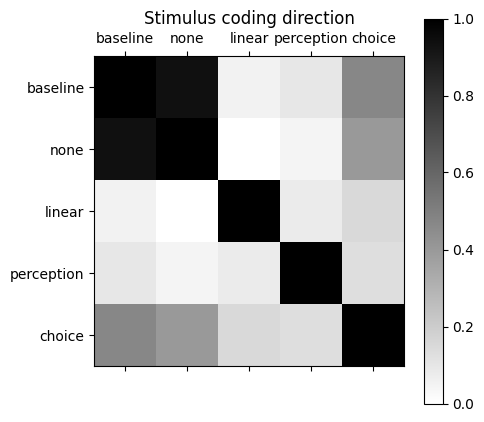

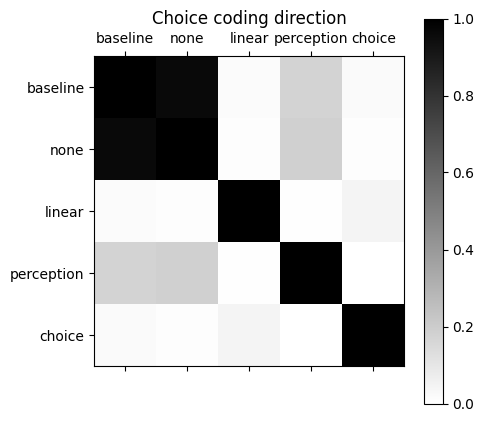

In [48]:
stim_ov_mat = np.zeros([len(conditions), len(conditions)])
choice_ov_mat = np.zeros([len(conditions), len(conditions)])
for i_condition, condition_i in enumerate(conditions):
    for j_condition, condition_j in enumerate(conditions):
        v_stim_i = dPCA_results[condition_i]['dpca'].P['st'][:, 0]
        v_stim_j = dPCA_results[condition_j]['dpca'].P['st'][:, 0]
        stim_ov_mat[i_condition, j_condition] = overlap(v_stim_i, v_stim_j)
        v_choice_i = dPCA_results[condition_i]['dpca'].P['dt'][:, 0]
        v_choice_j = dPCA_results[condition_j]['dpca'].P['dt'][:, 0]
        choice_ov_mat[i_condition, j_condition] = overlap(v_choice_i, v_choice_j)
        
fig, ax = plt.subplots(figsize=(5, 5));
cmap = LinearSegmentedColormap.from_list('my_cmap', [(0, [1, 1, 1]), (1, [0, 0, 0])])
ax.matshow(stim_ov_mat, cmap=cmap);
ax.set_xticks(range(len(conditions)));
ax.set_xticklabels(conditions);
ax.set_yticks(range(len(conditions)));
ax.set_yticklabels(conditions);
ax.set_title('Stimulus coding direction');
plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), ax=ax);

# Figure 7E
# plt.savefig('plots/model/dpca_stimulus_coding_direction_overlaps.pdf');

fig, ax = plt.subplots(figsize=(5, 5));
cmap = LinearSegmentedColormap.from_list('my_cmap', [(0, [1, 1, 1]), (1, [0, 0, 0])])
ax.matshow(choice_ov_mat, cmap=cmap);
ax.set_xticks(range(len(conditions)));
ax.set_xticklabels(conditions);
ax.set_yticks(range(len(conditions)));
ax.set_yticklabels(conditions);
ax.set_title('Choice coding direction');
plt.colorbar(plt.cm.ScalarMappable(cmap=cmap), ax=ax);

# Figure 7E
# plt.savefig('plots/model/dpca_choice_coding_direction_overlaps.pdf');

In [49]:
print('Stimulus component overlaps:\n')
for i_condition, condition_i in enumerate(conditions):
    for j_condition, condition_j in enumerate(conditions):
        v_stim_i = dPCA_results[condition_i]['dpca'].P['st'][:, 0]
        v_stim_j = dPCA_results[condition_j]['dpca'].P['st'][:, 0]
        ov = overlap(v_stim_i, v_stim_j)
        print('    {} vs. {}: {:.4f}'.format(condition_i, condition_j, ov))
        
print('\nChoice component overlaps:\n')
for i_condition, condition_i in enumerate(conditions):
    for j_condition, condition_j in enumerate(conditions):
        v_choice_i = dPCA_results[condition_i]['dpca'].P['dt'][:, 0]
        v_choice_j = dPCA_results[condition_j]['dpca'].P['dt'][:, 0]
        ov = overlap(v_choice_i, v_choice_j)
        print('    {} vs. {}: {:.4f}'.format(condition_i, condition_j, ov))

Stimulus component overlaps:

    baseline vs. baseline: 1.0000
    baseline vs. none: 0.9467
    baseline vs. linear: 0.2076
    baseline vs. perception: 0.2439
    baseline vs. choice: 0.5574
    none vs. baseline: 0.9467
    none vs. none: 1.0000
    none vs. linear: 0.1648
    none vs. perception: 0.2025
    none vs. choice: 0.4983
    linear vs. baseline: 0.2076
    linear vs. none: 0.1648
    linear vs. linear: 1.0000
    linear vs. perception: 0.2315
    linear vs. choice: 0.2890
    perception vs. baseline: 0.2439
    perception vs. none: 0.2025
    perception vs. linear: 0.2315
    perception vs. perception: 1.0000
    perception vs. choice: 0.2753
    choice vs. baseline: 0.5574
    choice vs. none: 0.4983
    choice vs. linear: 0.2890
    choice vs. perception: 0.2753
    choice vs. choice: 1.0000

Choice component overlaps:

    baseline vs. baseline: 1.0000
    baseline vs. none: 0.9593
    baseline vs. linear: 0.0163
    baseline vs. perception: 0.1689
    baseline vs. ch

In [50]:
# stats on stimulus component projections
data = [(max_stim_projections[i_condition], condition) for i_condition, condition in enumerate(conditions)]

n_subjects = 16 # 'subjects' here are trial conditions (8 stims * 2 choices)
n_conditions = len(data)
subject = [i for i in range(n_subjects)] * n_conditions
condition, measurement = [], []
for i in range(n_conditions):
    condition += ['{}'.format(i)] * n_subjects
    measurement += data[i][0]
df = pd.DataFrame({
    'subject': subject,
    'condition': condition,
    'measurement': measurement
})

# Perform repeated measures ANOVA
rm_anova = AnovaRM(df, 'measurement', 'subject', within=['condition'])
results = rm_anova.fit()

# Print the results
display(results.anova_table)

# post-hoc tests
correction = scipy.special.comb(n_conditions, 2) # bonferroni correction for number of paired tests

print('\nPost-hoc tests (Bonferroni-adjusted p-values):\n')
for i in range(n_conditions - 1):
    for j in range(i + 1, n_conditions):
        x1, label1 = data[i]
        x2, label2 = data[j]
        print('    {} vs. {}: p = {:.4e}'.format(label1, label2, correction * scipy.stats.ttest_rel(x1, x2)[1]))

,F Value,Num DF,Den DF,Pr > F
condition,56.481801,4.0,60.0,1.121121e-19



Post-hoc tests (Bonferroni-adjusted p-values):

    baseline vs. none: p = 1.0548e-01
    baseline vs. linear: p = 5.6736e-06
    baseline vs. perception: p = 7.5311e-06
    baseline vs. choice: p = 2.3853e-05
    none vs. linear: p = 1.9137e-05
    none vs. perception: p = 2.7703e-05
    none vs. choice: p = 9.1648e-04
    linear vs. perception: p = 1.8270e-02
    linear vs. choice: p = 1.6076e-06
    perception vs. choice: p = 3.8654e-06


In [51]:
# stats on choice component projections
data = [(max_choice_projections[i_condition], condition) for i_condition, condition in enumerate(conditions)]

n_subjects = 16 # 'subjects' here are trial conditions (8 stims * 2 choices)
n_conditions = len(data)
subject = [i for i in range(n_subjects)] * n_conditions
condition, measurement = [], []
for i in range(n_conditions):
    condition += ['{}'.format(i)] * n_subjects
    measurement += data[i][0]
df = pd.DataFrame({
    'subject': subject,
    'condition': condition,
    'measurement': measurement
})

# Perform repeated measures ANOVA
rm_anova = AnovaRM(df, 'measurement', 'subject', within=['condition'])
results = rm_anova.fit()

# Print the results
display(results.anova_table)

# post-hoc tests
correction = scipy.special.comb(n_conditions, 2) # bonferroni correction for number of paired tests

print('\nPost-hoc tests (Bonferroni-adjusted p-values):\n')
for i in range(n_conditions - 1):
    for j in range(i + 1, n_conditions):
        x1, label1 = data[i]
        x2, label2 = data[j]
        print('    {} vs. {}: p = {:.4e}'.format(label1, label2, correction * scipy.stats.ttest_rel(x1, x2)[1]))

,F Value,Num DF,Den DF,Pr > F
condition,114.373522,4.0,60.0,2.328365e-27



Post-hoc tests (Bonferroni-adjusted p-values):

    baseline vs. none: p = 9.2759e+00
    baseline vs. linear: p = 1.0506e-10
    baseline vs. perception: p = 2.8133e-10
    baseline vs. choice: p = 2.5803e-10
    none vs. linear: p = 1.2730e-06
    none vs. perception: p = 1.3610e-06
    none vs. choice: p = 2.0232e-06
    linear vs. perception: p = 2.5393e-02
    linear vs. choice: p = 4.2476e-05
    perception vs. choice: p = 8.7827e-01
